[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsinghlab/pyaging/blob/main/tutorials/tutorial_cpgptgrimage3.ipynb) [![Open In nbviewer](https://img.shields.io/badge/View%20in-nbviewer-orange)](https://nbviewer.jupyter.org/github/rsinghlab/pyaging/blob/main/tutorials/tutorial_cpgptgrimage3.ipynb)

# 🧬 ⚙️ CpGPT Quick Setup Tutorial ⚙️ 🧬

Welcome to the CpGPT Quick Setup Tutorial! 👋 

In this notebook, we'll walk you through the fastest way of using CpGPT for your research.

## Table of Contents

1. [Setup Environment](#1-setup-environment)
2. [Retrieve DNA LLM Embeddings](#2-retrieve-dna-llm-embeddings)
3. [Download and Load Model](#3-download-and-load-model)
4. [Prepare Data Objects](#4-prepare-data-objects)
5. [Run Inference](#5-run-inference)

## 1. Setup Environment

We'll import the necessary Python packages and set up our environment for CpGPT. We'll be using a mix of standard data science libraries and CpGPT-specific modules. We'll also set some important variables that will be used throughout the notebook. Pay attention to these as you may need to adjust them based on your specific setup and requirements.

CpGPT model files and DNA-sequence dependencies are hosted on Hugging Face.
The next Python cell downloads any missing files into the standard Hugging Face cache and reuses them on later runs; no command-line download is needed.

In [ ]:
from cpgpt import download_cpgpt

resources = download_cpgpt(model="age_cot", species="human")

In [ ]:
# Random seed for reproducibility
RANDOM_SEED = 42

# Directory paths
DEPENDENCIES_DIR = "../dependencies"
DATA_DIR = "../data"
PROCESSED_DIR = "../tmp"

MODEL_NAME = "age_cot"

ARROW_DF_PATH = "../tmp.arrow"
ARROW_DF_FILTERED_PATH = "../tmp_filtered.arrow"

# The maximum context length to give to the model
MAX_INPUT_LENGTH = 10_000 # you might wanna go higher hardware permitting
MAX_ATTN_LENGTH = 1_000

LLM_DEPENDENCIES_DIR = str(resources.dependencies_path)
MODEL_CHECKPOINT_PATH = str(resources.checkpoint_path)
MODEL_CONFIG_PATH = str(resources.config_path)
MODEL_VOCAB_PATH = str(resources.vocab_path) if resources.vocab_path is not None else None

> **⚠️ Warning**
> 
> It is recommended to have a GPU for inference as CPU might be slow.
> 
> Reconstructing the methylome for a few hundred samples might take up to one hour on a CPU. ⌛
>
> This might be a great exercise in testing your patience.

### 1.2 Import packages


In [ ]:
# Standard library imports
import warnings
import os
import json

warnings.simplefilter(action="ignore", category=FutureWarning)

# Plotting imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyaging as pya
import seaborn as sns
import torch

# Lightning imports
from lightning.pytorch import seed_everything

# cpgpt-specific imports
from cpgpt.data.components.cpgpt_datasaver import CpGPTDataSaver
from cpgpt.data.cpgpt_datamodule import CpGPTDataModule
from cpgpt.trainer.cpgpt_trainer import CpGPTTrainer
from cpgpt.data.components.dna_llm_embedder import DNALLMEmbedder
from cpgpt.data.components.illumina_methylation_prober import IlluminaMethylationProber
from cpgpt.infer.cpgpt_inferencer import CpGPTInferencer
from cpgpt.model.cpgpt_module import m_to_beta

# Set random seed for reproducibility
seed_everything(RANDOM_SEED, workers=True)
try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except:
    pass

In [3]:
import pandas as pd
df = pd.read_csv("../tmp.csv", index_col=0).T
import pyaging as pya
df = pya.pp.epicv2_probe_aggregation(df)
df.to_feather("../tmp.arrow")
df.head()

|-----> 🏗️ Starting epicv2_probe_aggregation function
|-----> ⚙️ Looking for duplicated probes started
|-----------> in progress: 100.0000%
|-----------> There are 6094 duplicated probes in the data
|-----> ✅ Looking for duplicated probes finished [18.9475s]
|-----> ⚙️ Averaging duplicated probes started
|-----------> in progress: 100.0000%
|-----> ✅ Averaging duplicated probes finished [20.0051s]
|-----> 🎉 Done! [59.4156s]


,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,cg00000321,...,rs7660805,rs7746156,rs798149,rs845016,rs877309,rs9292570,rs9363764,rs951295,rs966367,rs9839873
S1,0.823163,0.969316,0.978050,0.986363,0.071792,0.975535,0.956781,0.972128,0.900093,0.311363,...,0.542146,0.825269,0.777343,0.969592,0.131724,0.893715,0.515239,0.225704,0.451857,0.985357
S2,0.838272,0.967063,0.985064,0.989300,0.044430,0.975210,0.978465,0.967762,0.901791,0.295592,...,0.946131,0.542155,0.915568,0.160445,0.502027,0.551261,0.484001,0.520984,0.432917,0.256168
S3,0.775996,0.980452,0.983189,0.986069,0.065880,0.973201,0.946817,0.964458,0.884474,0.265154,...,0.967130,0.090605,0.087559,0.403492,0.577467,0.027280,0.532325,0.937888,0.043897,0.675054
S4,0.722360,0.970498,0.986904,0.987814,0.086030,0.968984,0.967036,0.965894,0.895305,0.149802,...,0.087703,0.495230,0.462961,0.428919,0.546059,0.034064,0.987651,0.529503,0.475798,0.984049
S5,0.592192,0.969450,0.984100,0.988371,0.128492,0.961034,0.962659,0.959986,0.851407,0.304403,...,0.802006,0.452238,0.662192,0.171815,0.532566,0.404319,0.566042,0.572641,0.386918,0.375141


## 2. Retrieve DNA LLM Embeddings

To retrieve the DNA LLM Embeddings, there are two options:
- download the dependencies with all of the sequence embeddings for the CpG sites targeted by the Illumina arrays;
- generate from scratch using the DNA LLM directly for loci outside of the ones already available for download.

In [4]:
# First let's declare the inferencer
inferencer = CpGPTInferencer(dependencies_dir=DEPENDENCIES_DIR, data_dir=DATA_DIR)

cpgpt -CpGPTInferencer: Initializing class CpGPTInferencer.
cpgpt -CpGPTInferencer: Using device: cuda.
cpgpt -CpGPTInferencer: Using dependencies directory: ../dependencies
cpgpt -CpGPTInferencer: Using data directory: ../data
cpgpt -CpGPTInferencer: Failed to get available models: An error occurred (InvalidAccessKeyId) when calling the ListObjectsV2 operation: The AWS Access Key Id you provided does not exist in our records.
cpgpt -CpGPTInferencer: Failed to get available datasets: An error occurred (InvalidAccessKeyId) when calling the ListObjectsV2 operation: The AWS Access Key Id you provided does not exist in our records.


### 2.1 Use Downloaded Dependencies


The setup cell above retrieved the human DNA-sequence dependencies from Hugging Face. `LLM_DEPENDENCIES_DIR` points to that cached directory.

### 2.2 Generate DNA LLM Embeddings


To generate genomic embeddings for loci outside of the ones already available for download, we can use the `DNALLMEmbedder` class. We need the loci in a list with the following format from ENSEMBL: 'chromosome:position'. Be mindful as this function can take a long time to run dependending on your GPU. For instance, embeddings ~1M genomic loci from the Illumina arrays takes about 12h in an RTX 4090.

In [5]:
if not os.path.exists(LLM_DEPENDENCIES_DIR):

    # List CpG genomic locations
    example_genomic_locations = ['1:100000', '1:250500', 'X:2031253']

    # Declare required class
    embedder = DNALLMEmbedder(dependencies_dir=LLM_DEPENDENCIES_DIR)

    # Parse the embeddings
    embedder.parse_dna_embeddings(
        example_genomic_locations,
        "homo_sapiens",
        dna_llm="nucleotide-transformer-v2-500m-multi-species",
        dna_context_len=2001,
    )

## 3. Download and Load Model

Please first check the model zoo for the available models and their corresponding features on the README.md file. To load any given model, you first need to define the dictionary structure with the hyperparameters and use the `CpGPTInferencer` class.

### 3.1 Use Downloaded Checkpoint and Configuration Files

### 3.2 Load Model

In [5]:
# Load the model configuration
config = inferencer.load_cpgpt_config(MODEL_CONFIG_PATH)

# Load the model weights
model = inferencer.load_cpgpt_model(
    config,
    model_ckpt_path=MODEL_CHECKPOINT_PATH,
    strict_load=True,
)

cpgpt -CpGPTInferencer: Loaded CpGPT model config.
cpgpt -CpGPTInferencer: Instantiated CpGPT model from config.


cpgpt -CpGPTInferencer: Using device: cuda.
cpgpt -CpGPTInferencer: Loading checkpoint from: ../dependencies/model/weights/age_cot.ckpt
cpgpt -CpGPTInferencer: Checkpoint loaded into the model.


## 4 Prepare Data Objects

In order to perform inference, we need to prepare the data objects, which are essentially memory-mapped versions for faster loading. As an example, let's download a toy dataset from the _CpGCorpus_ database.

### 4.1 Download and Load Toy Data

In [8]:
inferencer.download_cpgcorpus_dataset("GSE182215")

cpgpt: CpGPTInferencer: Dataset GSE182215 already exists at ../data/cpgcorpus/raw/GSE182215 (skipping download).


True

There is no need to impute the methylation data for CpGPT -- it simply ignores the missing values.

In [6]:
df = pd.read_feather(ARROW_DF_PATH)
# df.set_index('GSM_ID', inplace=True)
df.head()

,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,cg00000321,...,rs7660805,rs7746156,rs798149,rs845016,rs877309,rs9292570,rs9363764,rs951295,rs966367,rs9839873
S1,0.823163,0.969316,0.978050,0.986363,0.071792,0.975535,0.956781,0.972128,0.900093,0.311363,...,0.542146,0.825269,0.777343,0.969592,0.131724,0.893715,0.515239,0.225704,0.451857,0.985357
S2,0.838272,0.967063,0.985064,0.989300,0.044430,0.975210,0.978465,0.967762,0.901791,0.295592,...,0.946131,0.542155,0.915568,0.160445,0.502027,0.551261,0.484001,0.520984,0.432917,0.256168
S3,0.775996,0.980452,0.983189,0.986069,0.065880,0.973201,0.946817,0.964458,0.884474,0.265154,...,0.967130,0.090605,0.087559,0.403492,0.577467,0.027280,0.532325,0.937888,0.043897,0.675054
S4,0.722360,0.970498,0.986904,0.987814,0.086030,0.968984,0.967036,0.965894,0.895305,0.149802,...,0.087703,0.495230,0.462961,0.428919,0.546059,0.034064,0.987651,0.529503,0.475798,0.984049
S5,0.592192,0.969450,0.984100,0.988371,0.128492,0.961034,0.962659,0.959986,0.851407,0.304403,...,0.802006,0.452238,0.662192,0.171815,0.532566,0.404319,0.566042,0.572641,0.386918,0.375141


### 4.2 Filter Vocab Features and Save Data

While not strictly required, filtering for the features used in finetuning gives you the best chance of achieving good performance.

In [7]:
# Load list
vocab = json.load(open(MODEL_VOCAB_PATH, 'r'))

In [8]:
df = df.loc[:, df.columns.isin(vocab)]
df.head()

,cg00000292,cg00002426,cg00003994,cg00005847,cg00007981,cg00008493,cg00008713,cg00009407,cg00011459,cg00012199,...,cg27648946,cg27649764,cg27650175,cg27650434,cg27652350,cg27653134,cg27657283,cg27662379,cg27662877,cg27665659
S1,0.900093,0.875799,0.027109,0.155944,0.015754,0.973616,0.089676,0.029860,0.802090,0.035136,...,0.076441,0.015928,0.018106,0.128316,0.119681,0.945505,0.038699,0.027091,0.012977,0.061501
S2,0.901791,0.908206,0.022886,0.155695,0.013749,0.983115,0.073696,0.019293,0.760004,0.021624,...,0.083768,0.020092,0.025002,0.140191,0.144387,0.973732,0.036380,0.021752,0.029952,0.053726
S3,0.884474,0.895546,0.042779,0.131981,0.028297,0.980752,0.057163,0.038231,0.780634,0.036449,...,0.091504,0.013418,0.021807,0.148909,0.111786,0.956440,0.041021,0.027611,0.015132,0.061322
S4,0.895305,0.904610,0.016723,0.103900,0.016612,0.985287,0.048903,0.024200,0.904054,0.033051,...,0.103289,0.013643,0.021996,0.069549,0.143141,0.972440,0.026993,0.015523,0.019823,0.059483
S5,0.851407,0.848588,0.023067,0.412431,0.057130,0.986388,0.072811,0.024228,0.946695,0.035380,...,0.140507,0.015211,0.038425,0.112432,0.232257,0.898534,0.034835,0.026771,0.017186,0.040447


In [9]:
df.to_feather(ARROW_DF_FILTERED_PATH)

### 4.3 Memory-Map Data

In order to perform inference, we need to memory-map the data. This is done by using the `CpGPTDataSaver` class. We first need to define the `DNALLMEmbedder` and `IlluminaMethylationProber` classes, which contain the information about the DNA LLM Embeddings and the conversion between Illumina array probes to genomic locations, respectively.

In [10]:
embedder = DNALLMEmbedder(dependencies_dir=LLM_DEPENDENCIES_DIR)

cpgpt -DNALLMEmbedder: Initializing class DNALLMEmbedder.
cpgpt -DNALLMEmbedder: Genome files will be stored under ../dependencies/human/genomes.
cpgpt -DNALLMEmbedder: DNA embeddings will be stored under ../dependencies/human/dna_embeddings and subdirectories.
cpgpt -DNALLMEmbedder: Ensembl metadata dictionary loaded successfully


In [11]:
prober = IlluminaMethylationProber(dependencies_dir=LLM_DEPENDENCIES_DIR, embedder=embedder)

cpgpt -IlluminaMethylationProber: Initializing class IlluminaMethylationProber.
cpgpt -IlluminaMethylationProber: Illumina methylation manifest files will be stored under ../dependencies/human/manifests.
cpgpt -IlluminaMethylationProber: Illumina metadata dictionary loaded successfully.


In [12]:
# Define datasaver
quick_setup_datasaver = CpGPTDataSaver(data_paths=ARROW_DF_FILTERED_PATH, processed_dir=PROCESSED_DIR)

# Process the file
quick_setup_datasaver.process_files(prober, embedder)

cpgpt -CpGPTDataSaver: Initializing class CpGPTDataSaver.
cpgpt -CpGPTDataSaver: Dataset folders will be stored under ../tmp.
cpgpt -CpGPTDataSaver: No existing dataset metrics found. Please process files.
cpgpt -CpGPTDataSaver: No existing genomic locations found. Please process files.
cpgpt -CpGPTDataSaver: Starting file processing.


Output()

cpgpt -CpGPTDataSaver: No species column found. Defaulting to homo_sapiens.


cpgpt -CpGPTDataSaver: File processing completed.


### 4.4 Declare data module

Let's define two data modules: one for the forward pass and reconstructing the methylation, and another one the attention weights.

In [13]:
# Define datamodule
quick_setup_datamodule = CpGPTDataModule(
    predict_dir=PROCESSED_DIR,
    dependencies_dir=LLM_DEPENDENCIES_DIR,
    batch_size=1,
    num_workers=0,
    max_length=MAX_INPUT_LENGTH,
    dna_llm=config.data.dna_llm,
    dna_context_len=config.data.dna_context_len,
    sorting_strategy=config.data.sorting_strategy,
    pin_memory=False,
)

# Define datamodule
quick_setup_datamodule_attn = CpGPTDataModule(
    predict_dir=PROCESSED_DIR,
    dependencies_dir=LLM_DEPENDENCIES_DIR,
    batch_size=1,
    num_workers=0,
    max_length=MAX_ATTN_LENGTH,
    dna_llm=config.data.dna_llm,
    dna_context_len=config.data.dna_context_len,
    sorting_strategy=config.data.sorting_strategy,
    pin_memory=False,
)

cpgpt -DNALLMEmbedder: Initializing class DNALLMEmbedder.
cpgpt -DNALLMEmbedder: Genome files will be stored under ../dependencies/human/genomes.
cpgpt -DNALLMEmbedder: DNA embeddings will be stored under ../dependencies/human/dna_embeddings and subdirectories.
cpgpt -DNALLMEmbedder: Ensembl metadata dictionary loaded successfully
cpgpt -DNALLMEmbedder: Initializing class DNALLMEmbedder.
cpgpt -DNALLMEmbedder: Genome files will be stored under ../dependencies/human/genomes.
cpgpt -DNALLMEmbedder: DNA embeddings will be stored under ../dependencies/human/dna_embeddings and subdirectories.
cpgpt -DNALLMEmbedder: Ensembl metadata dictionary loaded successfully


## 5. Run Inference

There are several ways to perform inference with CpGPT. Here, we'll go through the most common ones. 

Different CUDA versions and GPU architectures may yield slightly different numerical results due to hardware-specific optimizations.

### 5.1 Declare Trainer

Given all models were trained under mixed precision, we'll use the `precision="16-mixed"` argument. However, if you finetune it using a different precision, you can change that accordingly.

In [14]:
trainer = CpGPTTrainer(precision="16-mixed")

Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 5.2 Get Sample Embeddings

In [18]:
quick_setup_sample_embeddings = trainer.predict(
    model=model,
    datamodule=quick_setup_datamodule,
    predict_mode="forward",
    return_keys=["sample_embedding"]
)

You are using a CUDA device ('NVIDIA A10G') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


cpgpt: CpGPTDataset: Initializing class CpGPTDataset.
cpgpt: CpGPTDataset: Loaded existing dataset metrics.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/data/miniforge3/envs/cpgpt/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


In [19]:
quick_setup_sample_embeddings

{'sample_embedding': tensor([[-0.0580, -0.0656, -0.0079,  ..., -0.0076, -0.1528, -0.0810],
         [-0.0750, -0.0756, -0.0059,  ..., -0.0241, -0.1455, -0.0859],
         [ 0.0325, -0.0363, -0.1413,  ..., -0.0782, -0.1645, -0.1452],
         ...,
         [-0.0838, -0.0999, -0.0362,  ...,  0.0130, -0.0523, -0.1371],
         [-0.0597, -0.0813, -0.0225,  ...,  0.0113, -0.1043, -0.0967],
         [-0.0248, -0.0809, -0.0548,  ...,  0.0250, -0.0796, -0.0924]])}

### 5.3 Predict Phenotypes

In [15]:
quick_setup_pred_conditions = trainer.predict(
    model=model,
    datamodule=quick_setup_datamodule,
    predict_mode="forward",
    return_keys=["pred_conditions"]
)

You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


cpgpt -CpGPTDataset: Initializing class CpGPTDataset.
cpgpt -CpGPTDataset: Loaded existing dataset metrics.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/data/miniforge3/envs/cpgpt/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Output()

In [23]:
df = pd.read_feather(ARROW_DF_PATH)

In [24]:
pd.DataFrame(quick_setup_pred_conditions['pred_conditions'].numpy()).to_csv('../tmp_pred_conditions.csv')

In [25]:
adata = pya.pp.df_to_adata(df, imputer_strategy='mean')

|-----> 🏗️ Starting df_to_adata function
|-----> ⚙️ Create anndata object started
|-----> ✅ Create anndata object finished [0.4413s]
|-----> ⚙️ Add metadata to anndata started
|-----------? No metadata provided. Leaving adata.obs empty
|-----> ⚠️ Add metadata to anndata finished [0.0009s]
|-----> ⚙️ Log data statistics started
|-----------> There are 12 observations
|-----------> There are 877300 features
|-----------> Total missing values: 0
|-----------> Percentage of missing values: 0.00%
|-----> ✅ Log data statistics finished [0.0107s]
|-----> ⚙️ Impute missing values started
|-----------> No missing values found. No imputation necessary
|-----> ✅ Impute missing values finished [0.0413s]
|-----> 🎉 Done! [0.4984s]


In [31]:
pya.pred.predict_age(adata, ['horvath2013', 'pcskinandblood', 'skinandblood'])

|-----> 🏗️ Starting predict_age function
|-----> ⚙️ Set PyTorch device started
|-----------> Using device: cuda
|-----> ✅ Set PyTorch device finished [0.0013s]
|-----> 🕒 Processing clock: horvath2013
|-----------> ⚙️ Load clock started
|-----------------> Downloading data to pyaging_data/horvath2013.pt
|-----------------> in progress: 100.0000%
|-----------> ✅ Load clock finished [0.1065s]
|-----------> ⚙️ Check features in adata started
|-----------------? 13 out of 353 features (3.68%) are missing: ['cg01873645', 'cg07595943', 'cg11932564'], etc.
|-----------------> Using reference feature values for horvath2013
|-----------> ⚠️ Check features in adata finished [0.1949s]
|-----------> ⚙️ Predict ages with model started
|-----------------> There is no preprocessing necessary
|-----------------> The postprocessing method is anti_log_linear
|-----------------> in progress: 100.0000%
|-----------> ✅ Predict ages with model finished [0.0015s]
|-----------> ⚙️ Add predicted ages and clock 

In [28]:
adata.obs['cpgpt_age_cot'] = quick_setup_pred_conditions['pred_conditions'].numpy()

In [ ]:
adata.obs.to_csv('../tmp_pred_conditions.csv')

: 

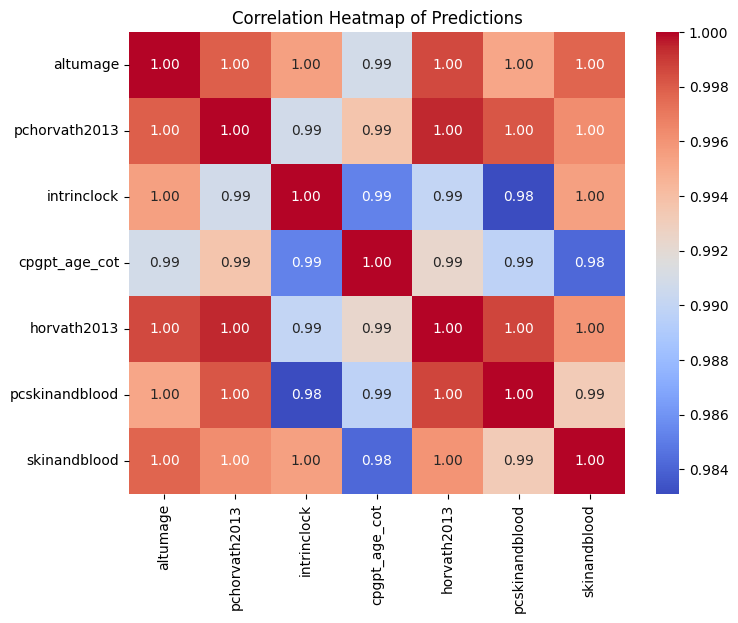

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = adata.obs.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Predictions")
plt.show()

### 5.4 Reconstruct Methylation

As an example, let's get some the reconstructed methylation values for some locations of interest based on the Illumina probes.

In [22]:
# Random probes for demonstration
probes = list(df.columns[0:100])

probes[0:5]

['cg00000292', 'cg00002426', 'cg00003994', 'cg00005847', 'cg00008493']

In [23]:
# Convert probes to genomic locations
genomic_locations = prober.locate_probes(probes, "homo_sapiens")

genomic_locations[0:5]

['16:28878778', '3:57757815', '7:15686236', '2:176164344', '14:93347430']

In [24]:
quick_setup_pred_meth = trainer.predict(
    model=model,
    datamodule=quick_setup_datamodule,
    predict_mode="reconstruct",
    genomic_locations=genomic_locations,
    species="homo_sapiens",
    return_keys=["pred_meth"],
)

cpgpt: CpGPTDataset: Initializing class CpGPTDataset.
cpgpt: CpGPTDataset: Loaded existing dataset metrics.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Be mindful as the reconstructed values are M values, not beta values. Therefore, you need to convert them to beta values using the `m_to_beta` function.

In [25]:
quick_setup_pred_meth["pred_meth"] = m_to_beta(quick_setup_pred_meth["pred_meth"])
quick_setup_pred_meth

{'pred_meth': tensor([[0.8501, 0.8633, 0.0503,  ..., 0.0348, 0.9292, 0.7095],
         [0.8706, 0.8833, 0.0492,  ..., 0.0340, 0.9419, 0.7275],
         [0.3799, 0.4067, 0.2776,  ..., 0.3308, 0.4133, 0.2937],
         ...,
         [0.7925, 0.7881, 0.0529,  ..., 0.0367, 0.9351, 0.7075],
         [0.8247, 0.8291, 0.0523,  ..., 0.0337, 0.9351, 0.7031],
         [0.6494, 0.4927, 0.0576,  ..., 0.0337, 0.9385, 0.7085]],
        dtype=torch.float16)}

A more powerful way of reconstructing the methylation values is using chain-of-thought. With additional test-time compute, we can let the model "think harder" about the problem, which can lead to better performance. However, it also takes considerably longer dependending on the number of thinking steps.

In [26]:
quick_setup_pred_meth_cot = trainer.predict(
    model=model,
    datamodule=quick_setup_datamodule,
    predict_mode="reconstruct",
    genomic_locations=genomic_locations,
    species="homo_sapiens",
    n_thinking_steps=5,
    thinking_step_size=1000,
    uncertainty_quantile=0.1,
    return_keys=["pred_meth"],
)

cpgpt: CpGPTDataset: Initializing class CpGPTDataset.
cpgpt: CpGPTDataset: Loaded existing dataset metrics.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [27]:
quick_setup_pred_meth_cot["pred_meth"] = m_to_beta(quick_setup_pred_meth_cot["pred_meth"])
quick_setup_pred_meth_cot

{'pred_meth': tensor([[0.8516, 0.8486, 0.0482,  ..., 0.0344, 0.9248, 0.7080],
         [0.8691, 0.8696, 0.0484,  ..., 0.0330, 0.9434, 0.7383],
         [0.4485, 0.4104, 0.3074,  ..., 0.3823, 0.3540, 0.2976],
         ...,
         [0.7856, 0.7690, 0.0512,  ..., 0.0355, 0.9326, 0.6919],
         [0.8271, 0.8198, 0.0520,  ..., 0.0332, 0.9331, 0.6934],
         [0.6523, 0.4868, 0.0560,  ..., 0.0331, 0.9297, 0.7061]],
        dtype=torch.float16)}

### 5.5 Analyze Attention Weights

The amount of memory required to store the attention weights is enormous. Therefore, we only use 1000 features for the demonstration. Also, remember that the the first token is the CLS token.

In [28]:
quick_setup_attn = trainer.predict(
    model=model,
    datamodule=quick_setup_datamodule_attn,
    predict_mode="attention",
    aggregate_heads="mean",
    layer_index=-1,
    return_keys=["attention_weights", "chroms", "positions", "mask_na", "meth"],
)

cpgpt: CpGPTDataset: Initializing class CpGPTDataset.
cpgpt: CpGPTDataset: Loaded existing dataset metrics.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [29]:
quick_setup_attn

{'attention_weights': tensor([[[0.0011, 0.0010, 0.0009,  ...,    nan,    nan,    nan],
          [0.0010, 0.0010, 0.0010,  ...,    nan,    nan,    nan],
          [0.0010, 0.0010, 0.0010,  ...,    nan,    nan,    nan],
          ...,
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan]],
 
         [[0.0011, 0.0010, 0.0010,  ...,    nan,    nan,    nan],
          [0.0010, 0.0011, 0.0010,  ...,    nan,    nan,    nan],
          [0.0010, 0.0010, 0.0010,  ...,    nan,    nan,    nan],
          ...,
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
          [   nan,    nan,    nan,  ...,    nan,    nan,    nan]],
 
         [[0.0121, 0.0115, 0.0097,  ...,    nan,    nan,    nan],
          [0.0114, 0.0123, 0.0098,  ...,    nan,    nan,    nan],
          [0.0105, 

: 